## Import Libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score,recall_score,f1_score,roc_auc_score,roc_curve
import warnings
from joblib import dump


warnings.filterwarnings("ignore")
sns.set(style='whitegrid')

# Load Dataset

In [2]:
df=pd.read_csv("Fraud_Analysis_Dataset.csv")

# Dataset Basic Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


# Statistics For Numerical Columns

In [4]:
# by default it gives statistical summury of numerical only
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


# Statistics For Categorical Columns

In [5]:
df.describe(include="object")

,type,nameOrig,nameDest
count,11142,11142,11142
unique,5,11142,7508
top,PAYMENT,C1305486145,C985934102
freq,5510,1,62


#                                                            EDA

In [6]:
# define categorical columns
cat_col=df.select_dtypes(include="object").columns
# define numerical columns
num_col=df.select_dtypes(exclude="object").columns

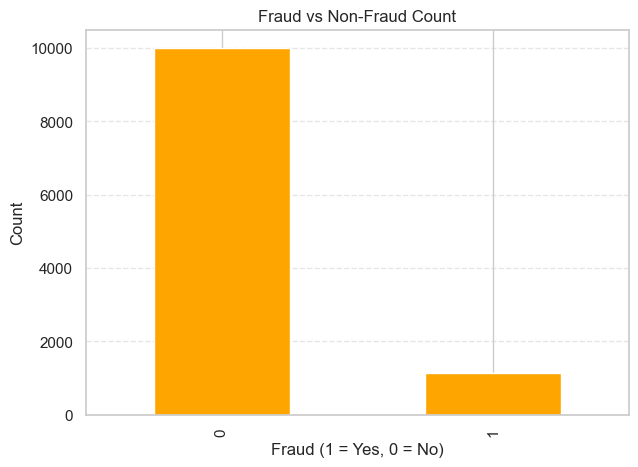

In [7]:
# 1. Fraud vs Non-Fraud Count

plt.figure(figsize=(7,5))
df['isFraud'].value_counts().plot(kind='bar', color='orange')
plt.title("Fraud vs Non-Fraud Count")
plt.xlabel("Fraud (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

* Insight

Fraud cases are much fewer compared to non-fraud.

This dataset is imbalanced, meaning you must use SMOTE, class weights, or balanced sampling while training ML models.

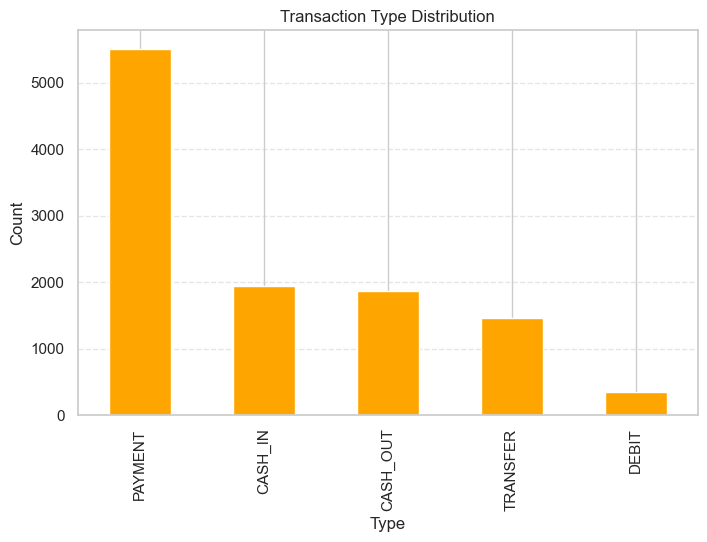

In [8]:
# 2. Transaction Type Distribution

plt.figure(figsize=(8,5))
df['type'].value_counts().plot(kind='bar', color='orange')
plt.title("Transaction Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


* Insight

PAYMENT transactions are the most common.

TRANSFER and CASH_OUT are known to be highly associated with fraud in many real-world datasets.

You may want to isolate specific transaction types for fraud modeling.

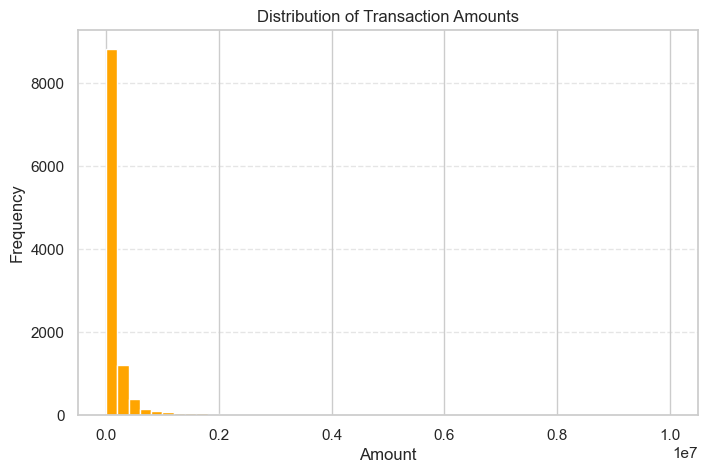

In [9]:
# 3. Distribution of Transaction Amounts

plt.figure(figsize=(8,5))
plt.hist(df['amount'], bins=50, color='orange')
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

* Insight

Most transactions are very small.

A few transactions are extremely large (millions), creating a heavy right skew.

Fraudsters often attempt abnormally large amounts.

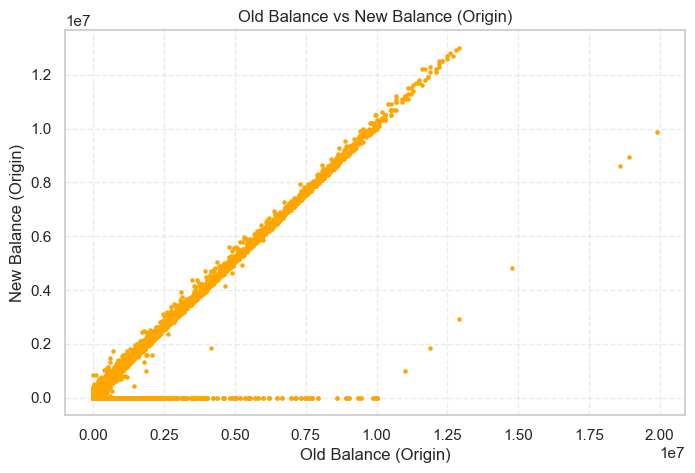

In [10]:
# 4. Old vs New Balance (Origin)

plt.figure(figsize=(8,5))
plt.scatter(df['oldbalanceOrg'], df['newbalanceOrig'], s=5, color='orange')
plt.title("Old Balance vs New Balance (Origin)")
plt.xlabel("Old Balance (Origin)")
plt.ylabel("New Balance (Origin)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

* Insight

Many transactions follow a straight-line pattern → amount deducted correctly.

Many points drop to zero new balance, meaning account was emptied.

Suspicious transactions often show large drop to zero or inconsistent patterns.

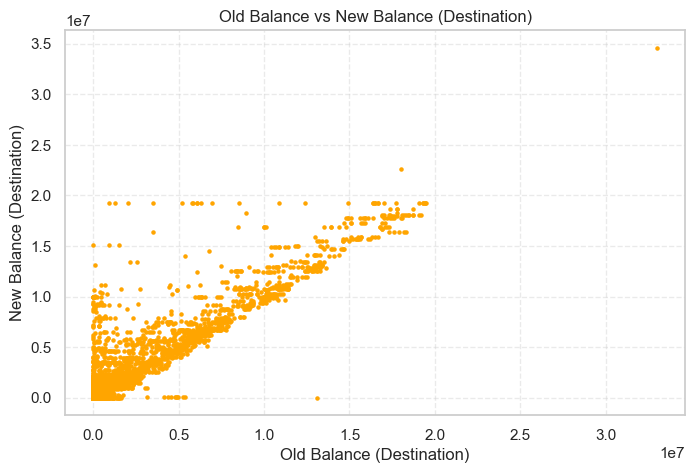

In [11]:
# 5. Old vs New Balance (Destination)

plt.figure(figsize=(8,5))
plt.scatter(df['oldbalanceDest'], df['newbalanceDest'], s=5, color='orange')
plt.title("Old Balance vs New Balance (Destination)")
plt.xlabel("Old Balance (Destination)")
plt.ylabel("New Balance (Destination)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

* Insight

Receivers often go from 0 to large values suddenly.

Fraud transactions frequently show sudden big balance increases.

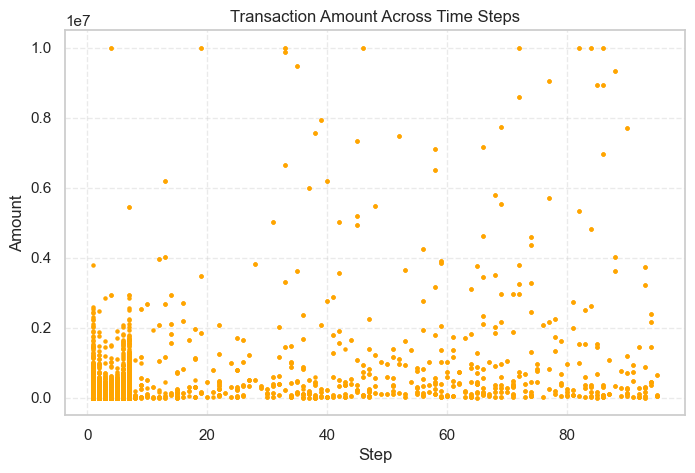

In [12]:
# 7. Step vs Amount Scatter Plot

plt.figure(figsize=(8,5))
plt.scatter(df['step'], df['amount'], s=5, color='orange')
plt.title("Transaction Amount Across Time Steps")
plt.xlabel("Step")
plt.ylabel("Amount")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

* Insight

High-value transactions happen throughout time.

No clear trend — fraud can occur at any time step.

Some time steps have dense activity (clusters), useful for temporal modeling.

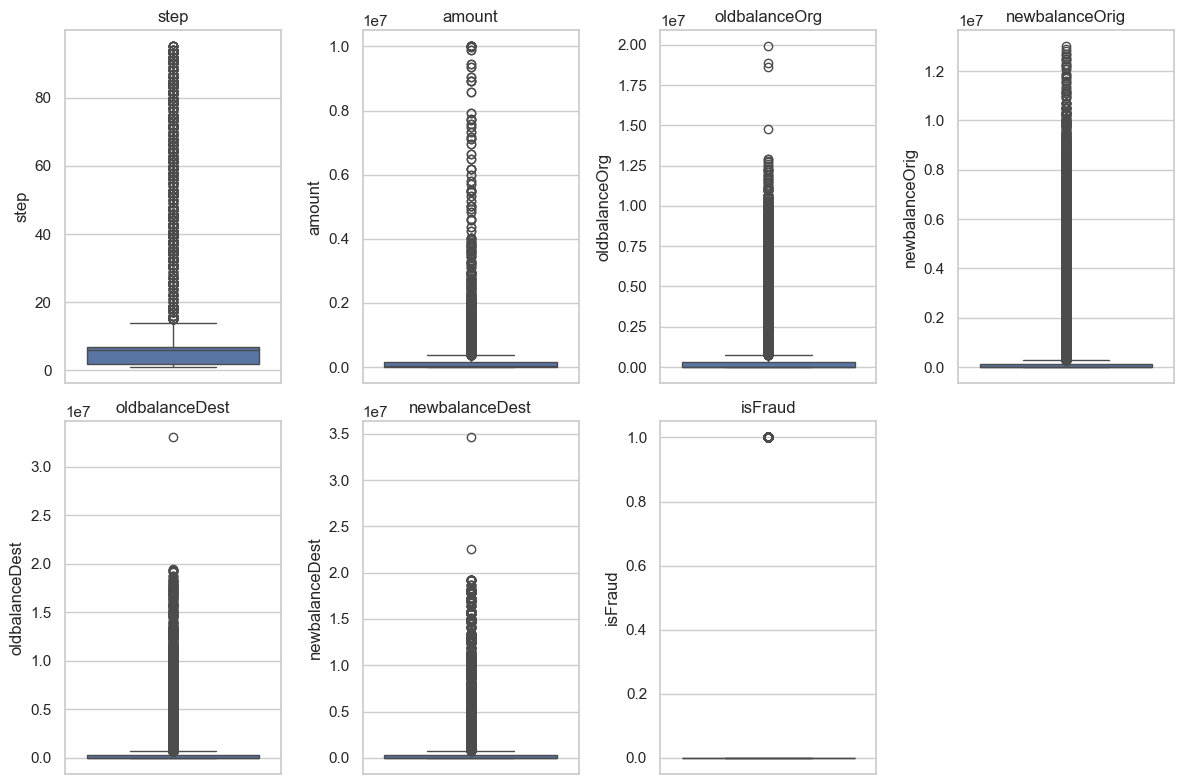

In [13]:
# boxplot for outlier detection

plt.figure(figsize=(12,8))

for i, col in enumerate(num_col, 1):
    plt.subplot(2,4, i)      
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.savefig("Outlier.png")
plt.show()

<Axes: title={'center': 'Correlation of Attributes'}>

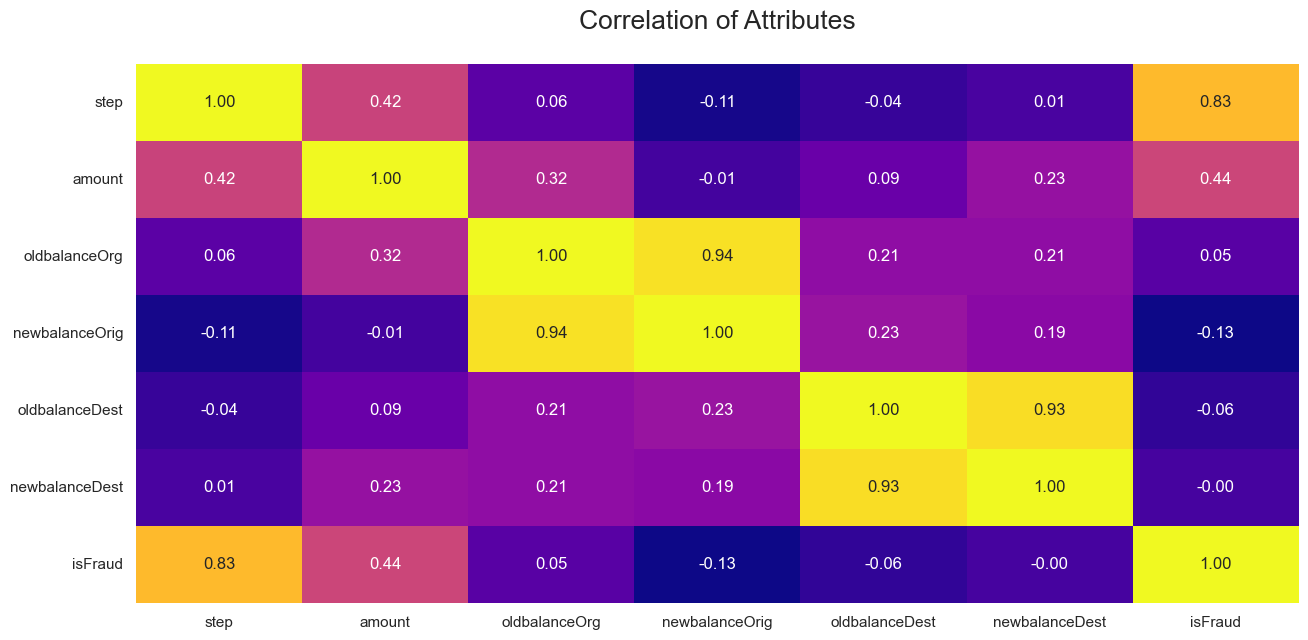

In [14]:
# corr
plt.figure(figsize = (15,7))
plt.title('Correlation of Attributes', y=1.05, size=19)
sns.heatmap(df.corr(numeric_only=True), cmap='plasma',annot=True, fmt='.2f', cbar=False)

# Feature Engineering

In [15]:
 # 1. Difference in balances (before - after) for origin and destination
df['origDiff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['destDiff'] = df['oldbalanceDest'] - df['newbalanceDest']

df.fillna(0, inplace=True)


# Data Preprocessing

* Correlation Of Attributes After Feature Engineering

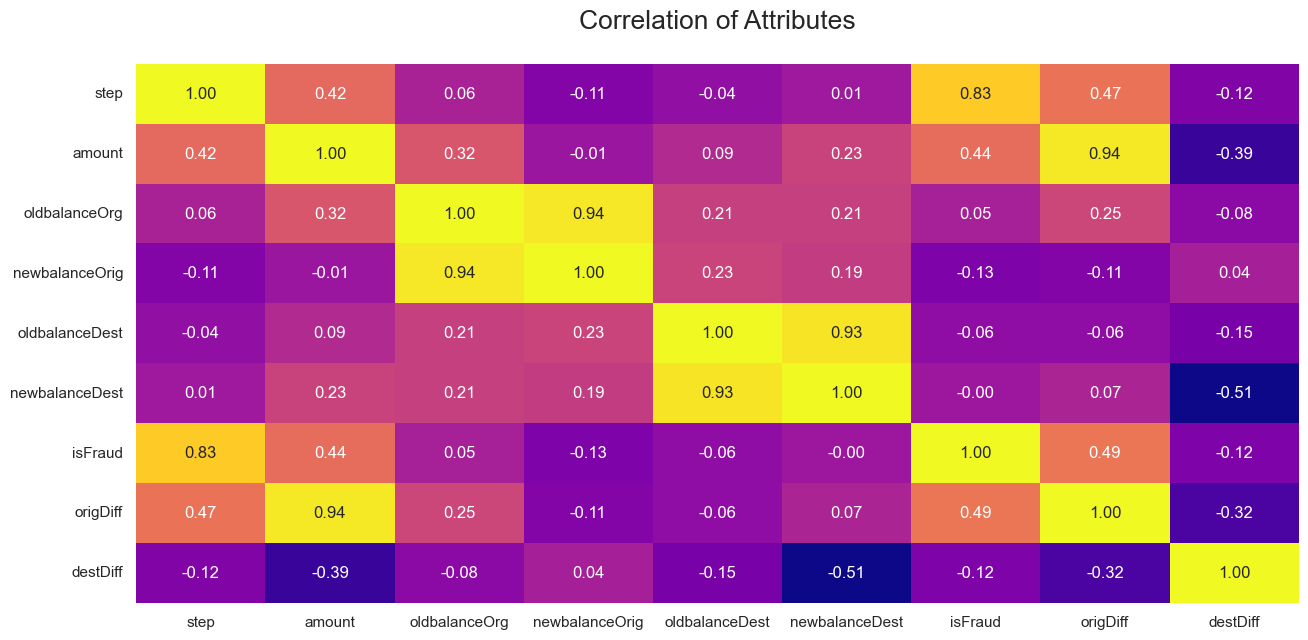

In [16]:
plt.figure(figsize = (15,7))
plt.title('Correlation of Attributes', y=1.05, size=19)
sns.heatmap(df.corr(numeric_only=True), cmap='plasma',annot=True, fmt='.2f', cbar=False)
plt.savefig("Correlation after feture engineering.png")

* Drop Irrelivent Columns

In [17]:
df.drop(["nameOrig","nameDest","newbalanceDest","oldbalanceDest"],axis=1,inplace=True)

* Handle Missing Value

In [18]:
df.isnull().sum()

step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
isFraud           0
origDiff          0
destDiff          0
dtype: int64

In [19]:
# new numerical columns after feature engineering
new_num_col=df.select_dtypes(exclude="object").columns

* Handle Outlier

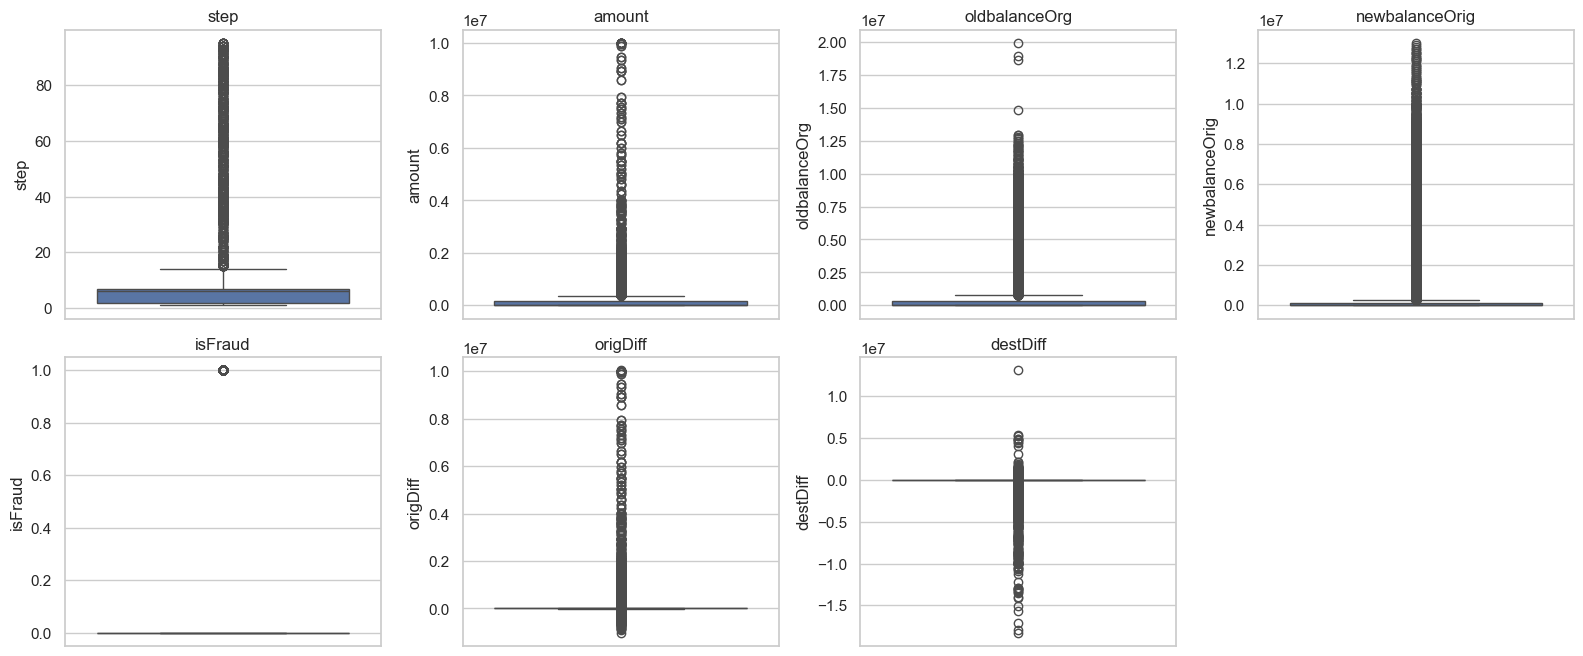

In [20]:
plt.figure(figsize=(16,10))

for i, col in enumerate(new_num_col, 1):
    plt.subplot(3,4,i)      
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [21]:
# count the outliers from numerical columns
Q1 = df[new_num_col].quantile(0.25)
Q3 = df[new_num_col].quantile(0.75)
IQR = Q3 - Q1
outliers_count = ((df[new_num_col] < (Q1 - 1.5 * IQR)) | (df[new_num_col] > (Q3 + 1.5 * IQR))).sum()

outliers_count


step               975
amount            1172
oldbalanceOrg     2195
newbalanceOrig    2245
isFraud           1142
origDiff          3405
destDiff          4866
dtype: int64

In [22]:
# here we use RobustScaler() to handle outlier.
df[new_num_col]=RobustScaler().fit_transform(df[new_num_col])

In [23]:
# encode the categorical columns
new_cat_col=df.select_dtypes(include="object").columns
for col in new_cat_col:
    df[col]=LabelEncoder().fit_transform(df[col])

# Select X(Independent Feature) and Y(Dependent Feature)

In [24]:
X=df.drop("isFraud",axis=1)

In [25]:
y=df["isFraud"]

# Split Trainning and Testing Data

In [26]:
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

* As targer is imbalance so here we use oversampling technique which is SMOTE()

In [27]:
smote=SMOTE(k_neighbors=5,sampling_strategy=0.3,random_state=42)

In [28]:
X_train_res,y_train_res=smote.fit_resample(X_train,y_train)

# Logistic Regression 

* Train Model

In [29]:
logistic_model=LogisticRegression()
logistic_model.fit(X_train_res,y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


* Model Evaluation

In [30]:
print(accuracy_score(y_test,logistic_model.predict(X_test)))

0.9889320969189351


In [31]:
print("Training Accuracy:", accuracy_score(y_train_res, logistic_model.predict(X_train_res)))
print("Testing Accuracy:", accuracy_score(y_test, logistic_model.predict(X_test)))

Training Accuracy: 0.9848351648351649
Testing Accuracy: 0.9889320969189351


In [32]:
print(classification_report(y_test,logistic_model.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      3000
         1.0       0.98      0.91      0.94       343

    accuracy                           0.99      3343
   macro avg       0.99      0.95      0.97      3343
weighted avg       0.99      0.99      0.99      3343



# Random Forest

* Train Model

In [33]:
ran_for_model=RandomForestClassifier()
ran_for_model.fit(X_train_res,y_train_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


* Model Evaluation

In [34]:
print(accuracy_score(y_test,ran_for_model.predict(X_test)))

0.9976069398743643


In [35]:
print("Training Accuracy:", accuracy_score(y_train_res, ran_for_model.predict(X_train_res)))
print("Testing Accuracy:", accuracy_score(y_test, ran_for_model.predict(X_test)))

Training Accuracy: 1.0
Testing Accuracy: 0.9976069398743643


In [36]:
print(classification_report(y_test,ran_for_model.predict(X_test)))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3000
         1.0       1.00      0.98      0.99       343

    accuracy                           1.00      3343
   macro avg       1.00      0.99      0.99      3343
weighted avg       1.00      1.00      1.00      3343



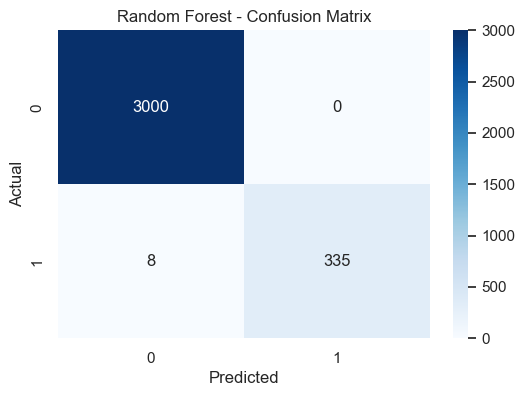

In [37]:
cm = confusion_matrix(y_test, ran_for_model.predict(X_test))
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()


In [38]:
importance=ran_for_model.feature_importances_
importance

array([0.50023272, 0.03430063, 0.06169993, 0.04853955, 0.04417771,
       0.27511982, 0.03592964])

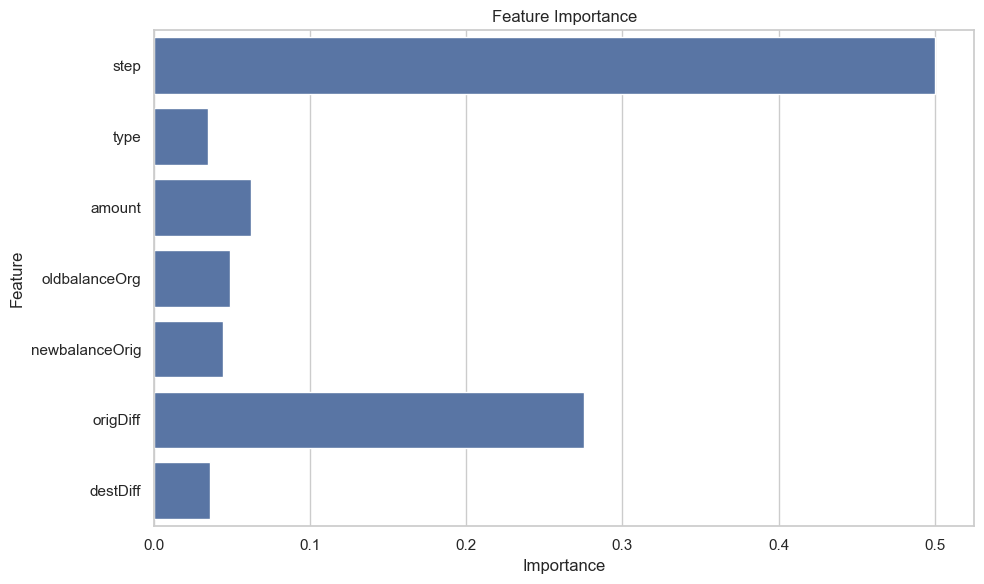

In [39]:
plt.figure(figsize=(10,6))
sns.barplot(x=importance, y=X_train_res.columns)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Decision Tree

* Train Model

In [40]:
Dec_tree_model=DecisionTreeClassifier()
Dec_tree_model.fit(X_train_res,y_train_res)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


* Model Evaluation

In [41]:
print(accuracy_score(y_test,Dec_tree_model.predict(X_test)))

0.9949147472330242


In [42]:
print("Training Accuracy:", accuracy_score(y_train_res, Dec_tree_model.predict(X_train_res)))
print("Testing Accuracy:", accuracy_score(y_test, Dec_tree_model.predict(X_test)))

Training Accuracy: 1.0
Testing Accuracy: 0.9949147472330242


In [43]:
print(classification_report(y_test,Dec_tree_model.predict(X_test)))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3000
         1.0       0.98      0.97      0.98       343

    accuracy                           0.99      3343
   macro avg       0.99      0.98      0.99      3343
weighted avg       0.99      0.99      0.99      3343



# SVM

* Train Model

In [44]:
svc_model=SVC()
svc_model.fit(X_train_res,y_train_res)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


* Model Evaluation

In [45]:
print(accuracy_score(y_test,svc_model.predict(X_test)))

0.961411905474125


In [46]:
print("Training Accuracy:", accuracy_score(y_train_res, svc_model.predict(X_train_res)))
print("Testing Accuracy:", accuracy_score(y_test, svc_model.predict(X_test)))

Training Accuracy: 0.9215384615384615
Testing Accuracy: 0.961411905474125


In [47]:
print(classification_report(y_test,svc_model.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98      3000
         1.0       0.98      0.64      0.77       343

    accuracy                           0.96      3343
   macro avg       0.97      0.82      0.88      3343
weighted avg       0.96      0.96      0.96      3343



In [54]:
dump((ran_for_model,RobustScaler()),"Save_model.plk")

['Save_model.plk']